In [254]:
import re
from typing import Literal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [255]:
df = pd.read_csv('../data/interim/full.csv').drop(columns='Unnamed: 0')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28991 entries, 0 to 28990
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_type          28991 non-null  object 
 1   price                  26454 non-null  float64
 2   area                   28989 non-null  float64
 3   area_unit              28989 non-null  object 
 4   n_bedrooms             17209 non-null  float64
 5   n_bathrooms            16374 non-null  float64
 6   n_floors               3352 non-null   float64
 7   address                28988 non-null  object 
 8   city_province          28991 non-null  object 
 9   district               28991 non-null  object 
 10  legal_docs             26031 non-null  object 
 11  facing_direction       12603 non-null  object 
 12  front_width            16648 non-null  float64
 13  price_unit             21048 non-null  object 
 14  front_width_unit       11956 non-null  object 
 15  fr

## Duplicates
Robust duplicates detection for cases:
  - Rescraping the same post
  - Multiple posts (inter-/intra-platform) about the same location

In [256]:
subset_features = ['address', 'property_type', 'area', 'price', 'n_bedrooms', 'n_bathrooms']

df_no_duplicates = df.drop_duplicates(subset=subset_features)

print(f"Number of rows before removing duplicates: {len(df)}")
print(f"Number of rows after removing duplicates: {len(df_no_duplicates)}")

df = df_no_duplicates

Number of rows before removing duplicates: 28991
Number of rows after removing duplicates: 21526


## Feature standardization
- Non-null `area`, `front_width`, `front_road_width` values are already unified   

To-dos:
- `price` to billion VND
- `property_type` to {"Nhà mặt tiền", "Nhà hẻm", "Biệt thự", "Chung cư", "Nhà riêng"}
  - Remove records that don't fall in these categories
- `legal_docs` to {"Sổ đỏ/hồng riêng", "Hợp đồng mua bán", "Sổ chung", "Đang chờ sổ", "Văn bản thỏa thuận", ""}
- Unify names for `city_province`
- Unify names for `district`

In [257]:
df.describe(include="all")

,property_type,price,area,area_unit,n_bedrooms,n_bathrooms,n_floors,address,city_province,district,legal_docs,facing_direction,front_width,price_unit,front_width_unit,front_road_width,front_road_width_unit,balcony_direction,interior
count,21526,19705.000000,2.152400e+04,21524,12489.000000,11895.000000,2438.000000,21523,21526,21526,19328,9081,12131.000000,16167,9196,8464.000000,8464,4277,8295
unique,18,NaN,NaN,1,NaN,NaN,NaN,10930,63,554,264,12,NaN,6,1,NaN,1,8,501
top,Căn hộ chung cư,NaN,NaN,m²,NaN,NaN,NaN,"Dự án Aria Bay Tower, Phường Hùng Thắng, Hạ Lo...",Hồ Chí Minh,Hạ Long,Sổ đỏ/ Sổ hồng,Đông - Nam,NaN,tỷ,m,NaN,m,Đông - Nam,Đầy đủ
freq,2249,NaN,NaN,21524,NaN,NaN,NaN,169,5252,970,10608,1899,NaN,14141,9196,NaN,8464,1340,3646
mean,NaN,39.306313,1.108996e+04,NaN,3.926816,3.618327,2.604594,NaN,NaN,NaN,NaN,NaN,31.415809,NaN,NaN,14.730302,NaN,NaN,NaN
std,NaN,243.165239,1.068693e+06,NaN,6.639253,6.190961,2.116898,NaN,NaN,NaN,NaN,NaN,1828.491405,NaN,NaN,14.578326,NaN,NaN,NaN
min,NaN,0.100000,1.050000e+00,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,3.500000,6.000000e+01,NaN,2.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,4.855000,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,7.800000,9.500000e+01,NaN,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,5.500000,NaN,NaN,12.000000,NaN,NaN,NaN
75%,NaN,23.000000,1.716250e+02,NaN,4.000000,4.000000,3.000000,NaN,NaN,NaN,NaN,NaN,9.600000,NaN,NaN,19.000000,NaN,NaN,NaN


### &emsp; Price

In [258]:
df["price_unit"].unique()

array([nan, 'tỷ', 'triệu', 'triệu/m²', 'nghìn/m²', 'tỷ/m²', 'nghìn'],
      dtype=object)

In [259]:
CONVERSION_MAP = {
    "tỷ": 1,
    "tỷ/m²": 1,
    "triệu": 1e-3,
    "triệu/m²": 1e-3,
    "nghìn/m²": 1e-6, 
    "nghìn": 1e-6   
}
def price_to_bil(row, val_col_label:str, unit_col_label:str):
    value = row[val_col_label]
    if not value:
        return None
    
    unit = row[unit_col_label]
    conversion_factor = CONVERSION_MAP.get(unit)
    if unit and conversion_factor:
        return value * conversion_factor
    else:        # from muaban_net.csv dataset
        return value

In [260]:
# convert all to million
df["price"] = df.apply(price_to_bil, axis=1, args=("price","price_unit"))

# convert price per m2 units to full price
price_per_area = df.price_unit.isin(["tỷ/m²", "triệu/m²", "nghìn/m²"])
df.loc[price_per_area, "price"] = df.loc[price_per_area, "price"] * df.loc[price_per_area, "area"]

### &emsp; Property type

In [261]:
df.property_type.unique()

array(['Nhà mặt tiền', 'Nhà hẻm ngõ', 'Biệt thự', 'Biệt thự, Villa',
       'Nhà hẻm, ngõ', 'Mặt tiền', 'Căn hộ chung cư',
       'Căn hộ chung cư mini', 'Nhà riêng', 'Nhà biệt thự, liền kề',
       'Nhà mặt phố', 'Shophouse, nhà phố thương mại', 'Đất nền dự án',
       'Đất', 'Condotel', 'Trang trại, khu nghỉ dưỡng', 'Kho, nhà xưởng',
       'Khác'], dtype=object)

In [262]:
df.loc[df.property_type.isin(['Nhà mặt tiền', 'Mặt tiền', 'Nhà mặt phố']), 'property_type'] = 'Nhà mặt tiền'
df.loc[df.property_type.isin(['Nhà hẻm ngõ', 'Nhà hẻm, ngõ']), 'property_type'] = 'Nhà hẻm ngõ'
df.loc[df.property_type.isin(['Biệt thự', 'Biệt thự, Villa', 'Nhà biệt thự, liền kề']), 'property_type'] = 'Biệt thự'
df.loc[df.property_type.isin(['Căn hộ chung cư', 'Căn hộ chung cư mini']), 'property_type'] = 'Căn hộ chung cư'

df = df.loc[df.property_type.isin(['Nhà mặt tiền', 'Nhà hẻm ngõ', 'Nhà riêng', 'Biệt thự', 'Căn hộ chung cư'])]

### &emsp;Legal docs

In [263]:
legals = df.legal_docs.unique()
legals

array(['Sổ hồng', 'Sổ đỏ', 'Giấy tờ hợp lệ', 'Giấy tờ khác',
       'Hợp đồng mua bán', 'Đang chờ sổ', 'Sổ hồng đầy đủ', 'HDMB',
       'Sổ đỏ/ Sổ hồng', 'Hợp đồng mua bán.', 'Sổ đỏ/ Sổ hồng.', 'HĐMB',
       nan, 'Sổ hồng riêng', 'Có sổ.', 'Sổ hồng đã hoàn công năm 2025',
       'Sổ hồng (sử dụng chung).',
       'Bùi Xương Trạch, khương đình, Thanh Xuân.',
       'Đã có sổ đỏ - mua bán vi bằng',
       'Sổ đỏ chính chủ, sẵn sàng giao dịch.', 'Sổ hồng.', 'Có sổ',
       'Có sổ( sử dụng chung).', 'Sổ hồng vĩnh viễn.',
       'Sổ đỏ/ Sổ hồng', 'Sổ đỏ.', 'Mua bán công chứng vi bằng',
       'Nhà đã có sổ đỏ.', 'Có sổ đỏ.', 'sổ đỏ sang tên',
       'Sổ đỏ chính chủ', 'Hợp đồng mua bán vi bằng',
       'Sổ đỏ/ Sổ hồng chung', 'Sổ đỏ sang tên.', 'Sổ đỏ sang tên',
       'Pháp lý: Giao dịch vi bằng, thủ tục nhanh gọn.', 'HĐ vi bằng',
       'Mỗi căn hộ có 1 bìa hồng. Mua bán lập HĐ vi bằng.', 'Đã có sổ',
       'Sổ đỏ/ Sổ hồng ( sử dụng chung)', 'Sổ hồng riêng.', 'Sổ hồng sdc',
       'S

In [264]:
def standardize_legal_doc_types(s: str) -> None|Literal['Sổ đỏ/hồng riêng', 'Hợp đồng mua bán', 'Sổ dùng chung', 'Văn bản thỏa thuận', 'Đang chờ sổ', 'Giấy tờ khác']:
    if not s or not isinstance(s, str) or not s.strip():
        return 'Khác/Không rõ'
    
    s = s.lower().strip()
    s = re.sub(r'[:,.-/()+]', '', s)

    if re.search(r'chờ sổ|chờ cấp sổ', s):
        return 'Đang chờ sổ'
    # 2 cái 'sổ' nhìn giống nhau nhưng khác (1 cái đầu có 3 kí tự là s, ô, dấu hỏi)
    if re.search(r'sổ|sổ|bìa hồng|sđ|bìa đỏ|có số|pháp\s*l[íý]:?\s*đầy đủ|đầy đủ\s*pháp\s*l[íý]|pháp\s*l[íý]\s*chuẩn|pháp\s*l[íý]\s*rõ\s*ràng|giấy tờ hợp lệ|sang tên',s):
        if re.search(r'sử dụng chung|sổ chung|đồng sở hữu|đồng sh|sdc|chung|đsh',s):
            return 'Sổ đỏ/hồng chung'
        return 'Sổ đỏ/hồng riêng'
    if re.search(r'vi bằng|vb|văn bản thoã thuận|vbtt|thỏa thuận|thoả thuận|đặt cọc|góp vốn',s):
        return 'Văn bản thỏa thuận'
    if re.search(r'hợp đồng mua bán|hđmb|hdmb|hợp đồng|hđ|hd', s):
        return 'Hợp đồng mua bán'
    else:
        return 'Khác/Không rõ'

In [265]:
# test function
transformed = {s:standardize_legal_doc_types(s) for s in legals}
transformed

{'Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ hợp lệ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ khác': 'Khác/Không rõ',
 'Hợp đồng mua bán': 'Hợp đồng mua bán',
 'Đang chờ sổ': 'Đang chờ sổ',
 'Sổ hồng đầy đủ': 'Sổ đỏ/hồng riêng',
 'HDMB': 'Hợp đồng mua bán',
 'Sổ đỏ/ Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Hợp đồng mua bán.': 'Hợp đồng mua bán',
 'Sổ đỏ/ Sổ hồng.': 'Sổ đỏ/hồng riêng',
 'HĐMB': 'Hợp đồng mua bán',
 nan: 'Khác/Không rõ',
 'Sổ hồng riêng': 'Sổ đỏ/hồng riêng',
 'Có sổ.': 'Sổ đỏ/hồng riêng',
 'Sổ hồng đã hoàn công năm 2025': 'Sổ đỏ/hồng riêng',
 'Sổ hồng (sử dụng chung).': 'Sổ đỏ/hồng chung',
 'Bùi Xương Trạch, khương đình, Thanh Xuân.': 'Khác/Không rõ',
 'Đã có sổ đỏ - mua bán vi bằng': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ chính chủ, sẵn sàng giao dịch.': 'Sổ đỏ/hồng riêng',
 'Sổ hồng.': 'Sổ đỏ/hồng riêng',
 'Có sổ': 'Sổ đỏ/hồng riêng',
 'Có sổ( sử dụng chung).': 'Sổ đỏ/hồng chung',
 'Sổ hồng vĩnh viễn.': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ/ Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ đ

In [266]:
df.loc[:,'legal_docs'] = df.legal_docs.apply(standardize_legal_doc_types)

In [267]:
df.legal_docs.unique()

array(['Sổ đỏ/hồng riêng', 'Khác/Không rõ', 'Hợp đồng mua bán',
       'Đang chờ sổ', 'Sổ đỏ/hồng chung', 'Văn bản thỏa thuận'],
      dtype=object)

### &emsp; City/Province

In [268]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa - Vũng Tàu',
       'Đắk Lắk', 'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa',
       'Nghệ An', 'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre',
       'Bình Định', 'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp',
       'Gia Lai', 'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum',
       'Lào Cai', 'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên',
       'Quảng Bình', 'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh',
       'Thái Bình', 'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế',
       'Trà Vinh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hồ Chí Minh',
       'Hòa Bình', 'Bà Rịa Vũng Tàu', 'Hải Dương', 'Hà Nam', 'Đắk Nông',
       'Ninh Bình', 'Sơn La'], dtype=object)

In [269]:
df.loc[df.city_province.isin(['Thành phố Hồ Chí Minh', 'thành phố Hồ Chí Minh', 'Hồ Chí Minh', 'TPHCM']), 'city_province'] = 'TP.HCM'
df.loc[df.city_province == 'Thành phố Hà Nội', 'city_province'] = 'Hà Nội'
df.loc[df.city_province == 'Bà Rịa - Vũng Tàu', 'city_province'] = 'Bà Rịa Vũng Tàu'

In [270]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa Vũng Tàu', 'Đắk Lắk',
       'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa', 'Nghệ An',
       'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre', 'Bình Định',
       'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp', 'Gia Lai',
       'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum', 'Lào Cai',
       'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình',
       'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh', 'Thái Bình',
       'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế', 'Trà Vinh',
       'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hòa Bình', 'Hải Dương',
       'Hà Nam', 'Đắk Nông', 'Ninh Bình', 'Sơn La'], dtype=object)

### &emsp;District

In [271]:
df.loc[df.city_province == "TP.HCM", "district"].unique()

array(['Quận 5', 'Quận 7', 'Quận 6', 'Huyện Bình Chánh', 'Quận 10',
       'Quận 3', 'Quận Gò Vấp', 'Quận 1', 'Quận 12', 'Quận Tân Bình',
       'Quận Tân Phú', 'Quận Bình Thạnh', 'Quận Bình Tân', 'Quận 11',
       'Quận Phú Nhuận', 'Huyện Nhà Bè', 'Quận 8', 'TP. Thủ Đức - Quận 2',
       'Huyện Hóc Môn', 'TP. Thủ Đức - Quận Thủ Đức',
       'TP. Thủ Đức - Quận 9', 'Huyện Cần Giờ', 'Quận 4', 'Huyện Củ Chi',
       'Quận 2', 'Quận 9', 'Nhà Bè', 'Tân Bình', 'Bình Thạnh', 'Bình Tân',
       'Gò Vấp', 'Bình Chánh', 'Tân Phú', 'Thủ Đức', 'Phú Nhuận',
       'Cần Giờ', 'Hóc Môn', 'Củ Chi'], dtype=object)

In [272]:
def standardize_district(s:str)->str:
    s = s.strip().lower()
    s = re.sub(r'\s*-\s*', ' - ', s)   # For Phan Rang - Tháp Chàm

    if 'thủ đức' in s or 'quận 2' in s or 'quận 9' in s:
        return 'Thủ Đức'
    if re.search(r'quận \d+',s):
        return re.search(r'quận \d+', s).group(0).title()
    return re.sub(r'quận|^huyện|tp.|thành phố|thị xã', '', s).strip().title()

In [273]:
test_std_distr = {s: standardize_district(s) for s in df.district.unique()}
test_std_distr

{'Quận 5': 'Quận 5',
 'Quận 7': 'Quận 7',
 'Quận 6': 'Quận 6',
 'Huyện Bình Chánh': 'Bình Chánh',
 'Quận 10': 'Quận 10',
 'Quận 3': 'Quận 3',
 'Quận Gò Vấp': 'Gò Vấp',
 'Quận 1': 'Quận 1',
 'Quận 12': 'Quận 12',
 'Quận Tân Bình': 'Tân Bình',
 'Quận Tân Phú': 'Tân Phú',
 'Quận Bình Thạnh': 'Bình Thạnh',
 'Quận Bình Tân': 'Bình Tân',
 'Quận 11': 'Quận 11',
 'Quận Phú Nhuận': 'Phú Nhuận',
 'Huyện Nhà Bè': 'Nhà Bè',
 'Quận 8': 'Quận 8',
 'TP. Thủ Đức - Quận 2': 'Thủ Đức',
 'Huyện Hóc Môn': 'Hóc Môn',
 'TP. Thủ Đức - Quận Thủ Đức': 'Thủ Đức',
 'TP. Thủ Đức - Quận 9': 'Thủ Đức',
 'Huyện Cần Giờ': 'Cần Giờ',
 'Quận 4': 'Quận 4',
 'Huyện Củ Chi': 'Củ Chi',
 'Quận Ba Đình': 'Ba Đình',
 'Quận Hoàn Kiếm': 'Hoàn Kiếm',
 'Quận Hoàng Mai': 'Hoàng Mai',
 'Quận Hai Bà Trưng': 'Hai Bà Trưng',
 'Huyện Đông Anh': 'Đông Anh',
 'Quận Long Biên': 'Long Biên',
 'Quận Bắc Từ Liêm': 'Bắc Từ Liêm',
 'Quận Tây Hồ': 'Tây Hồ',
 'Quận Hà Đông': 'Hà Đông',
 'Quận Thanh Xuân': 'Thanh Xuân',
 'Quận Đống Đa': 'Đống Đa'

In [274]:
df.loc[:,'district'] = df.district.apply(standardize_district)

In [275]:
df.loc[df.city_province == "Quảng Ninh", "district"].unique()

array(['Hạ Long', 'Cẩm Phả', 'Vân Đồn'], dtype=object)

In [276]:
df.loc[df.district=="Hạ Long"]

,property_type,price,area,area_unit,n_bedrooms,n_bathrooms,n_floors,address,city_province,district,legal_docs,facing_direction,front_width,price_unit,front_width_unit,front_road_width,front_road_width_unit,balcony_direction,interior
4734,Nhà hẻm ngõ,3.500,85.00,m²,4.0,3.0,3.0,"phố Độc lập, Đường Hà Lầm, Phường Hà Lầm, TP. ...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Nam,5.0,NaN,NaN,NaN,NaN,NaN,NaN
4735,Biệt thự,630.000,5000.00,m²,NaN,NaN,NaN,"Đường Hoàng Quốc Việt, Bãi Cháy, TP. Hạ Long, ...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN
7126,Căn hộ chung cư,1.550,30.00,m²,1.0,1.0,NaN,"ICON40 Hạ Long , Hoàng Quốc Việt, Hùng Thắng, ...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Nam,NaN,tỷ,NaN,NaN,NaN,Nam,Cơ bản
8801,Căn hộ chung cư,2.740,34.00,m²,1.0,1.0,NaN,"Sun Centro Town, Đường Kỳ Quan, Phường Bãi Chá...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Đông - Nam,NaN,tỷ,NaN,NaN,NaN,Đông - Nam,Cơ bản
9282,Nhà mặt tiền,56.000,351.14,m²,80.0,NaN,NaN,"Phường Hùng Thắng, Hạ Long, Quảng Ninh",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Bắc,24.0,tỷ,m,15.0,m,Bắc,Không nội thất
9927,Biệt thự,NaN,200.00,m²,3.0,3.0,NaN,"Dự án Grand Bay Halong Villas, Đường Hoàng Quố...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,NaN,NaN,NaN,NaN,30.0,m,NaN,Không nội thất
9944,Nhà mặt tiền,8.500,41.60,m²,1.0,1.0,NaN,"Đường Cái Dăm, Phường Bãi Cháy, Hạ Long, Quảng...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Tây - Nam,4.0,tỷ,m,21.0,m,NaN,NaN
9955,Nhà mặt tiền,8.000,41.00,m²,2.0,NaN,NaN,"Đường Cái Dăm, Phường Bãi Cháy, Hạ Long, Quảng...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,Tây - Nam,4.0,tỷ,m,15.0,m,NaN,Đầy đủ
10579,Biệt thự,40.000,255.00,m²,4.0,4.0,NaN,"Dự án Grand Bay Halong Villas, Đường Hoàng Quố...",Quảng Ninh,Hạ Long,Sổ đỏ/hồng riêng,NaN,NaN,tỷ,NaN,NaN,NaN,NaN,Đầy đủ
12971,Biệt thự,35.200,250.00,m²,3.0,3.0,NaN,"Dự án Grand Bay Halong Villas, Đường Hoàng Quố...",Quảng Ninh,Hạ Long,Hợp đồng mua bán,NaN,NaN,tỷ,NaN,NaN,NaN,NaN,Không nội thất


## Checkpoint 1: Analysis-ready data

In [ ]:
# df.to_csv('../data/processed/analysis_ready.csv')

## Visualization and Analysis (1)

<Axes: xlabel='price', ylabel='property_type'>

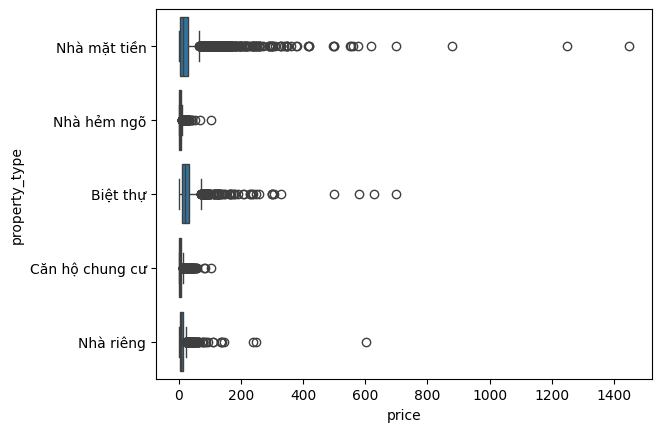

In [277]:
sns.boxplot(df, y='property_type', x='price')

In [279]:
def top_n(df, col_of_top:str, n=10, ascending=False):
    top_n = df.groupby(col_of_top).size().sort_values(ascending=ascending)[:n]
    return top_n.index

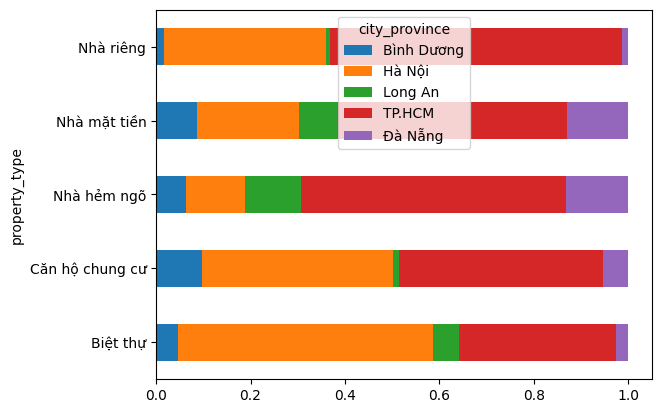

In [282]:
df_top_provinces = df[df.city_province.isin(top_n(df, 'city_province', n=5, ascending=False))]
ct = pd.crosstab(df_top_provinces['property_type'], df_top_provinces['city_province'])
ct = ct.div(ct.sum(axis=1), axis=0)
ct.plot(kind='barh', stacked=True)

plt.show()

## Missing values
- Missing percentage for all cols
- Deal with those missing values
- Visualize missing groups

## Outlier detection
- physically impossible values (e.g., $\text{area} \le 0$, $\text{n\_bedrooms} < 1$ for a house).
- deal with outliers/noise records

## Checkpoint 2: Cleaned dataset

In [281]:
# df.to_csv('../data/processed/cleaned.csv')